# Main Manuisript

## Figure 1

In [1]:
from pathlib import Path
import os

from analysis.analysis_utils import load_results

MODEL_DIR = Path(os.getcwd()) / "models"

normal_data = load_results(
    dir=MODEL_DIR, flatten=True, r2_cutoff=0.85, target=['kf', 'n']
)

kf_data = normal_data[normal_data['target'] == 'kf']
n_data = normal_data[normal_data['target'] == 'n']

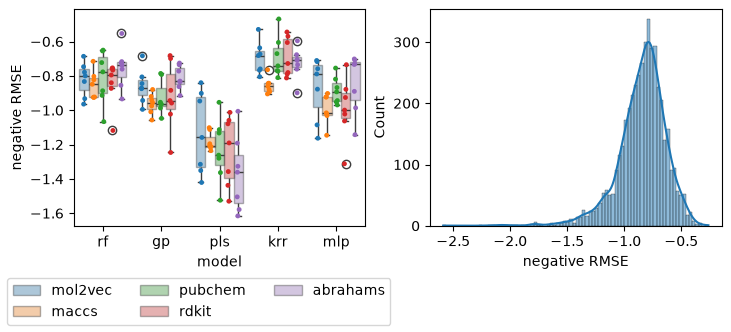

In [2]:
from matplotlib import pyplot as plt
import seaborn as sns

example_data = kf_data.loc[
    (kf_data['salinity'] == 'all_water') & ~kf_data['crange'] \
    & ~kf_data['temperature'] & (kf_data['sorbent'] == 'comp'), :
]
fig, axs = plt.subplots(ncols=2, figsize=(9*0.8, 4.5*0.72), layout='constrained')
sns.boxplot(
    data=example_data.explode(column='score').reset_index(), ax=axs[0],
    x='model', y='score', hue='fingerprint', boxprops={'alpha': 0.4},
)
handles, labels = axs[0].get_legend_handles_labels()
axs[0].get_legend().remove()
sns.stripplot(
    data=example_data.explode(column='score').reset_index(), ax=axs[0],
    x='model', y='score', hue='fingerprint', dodge=True, legend=False, s=3.5
)
axs[0].set(ylabel="negative RMSE")
fig.legend(
    handles, labels, loc='outside lower left',# bbox_to_anchor=(0.5, -0.05),
            ncols=3
)
sns.histplot(
    kf_data[(kf_data['model'] != 'pls')].explode('score').reset_index(drop=True),
    x = 'score', ax=axs[1], kde=True
)
axs[1].set(xlabel=("negative RMSE"))
# axs[1].axvline(
#     kf_data[(kf_data['model'] != 'pls')].explode('score').reset_index(drop=True)['score'].median(),
#     color='k', linestyle='dashed', linewidth=1
# )
os.makedirs(Path(os.getcwd()) / "plots" / "evaluation", exist_ok=True)
plt.savefig(Path(os.getcwd()) / "plots" / "evaluation" / "figure1.pdf", dpi=1500, bbox_inches="tight")
plt.show()

## Figure 2

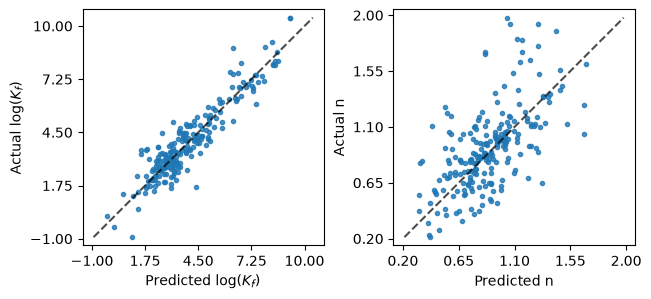

In [3]:
import numpy as np
import pickle
from matplotlib import pyplot as plt

from training.train_utils import model_path, model_name, DataSettings, ModelSettings
from sklearn.metrics import PredictionErrorDisplay

def example_model_path(target):
    krr_path = model_path(
    DataSettings(
        r2_cutoff=0.85, conc_range=True, salinity='all_vals',
        temperature=False, sorbent='name'),
    path_prefix=MODEL_DIR
    )
    krr_path /= model_name(ModelSettings(model='krr', embedding='abrahams', target=target))
    return krr_path


# actual vs predicted plots for example data (Figure 2)
fig, axs = plt.subplots(ncols=2, figsize=(8*0.8, 4*0.72), layout='constrained')
for tar, ax in zip(('kf', 'n'), axs):
    with open(example_model_path(tar), 'rb') as fh:
        (X, y), clf, grid, (inner_cv, outer_cv), score = pickle.load(fh)
    y_pred = np.zeros_like(y)
    for est, ind in zip(score['estimator'], score['indices']['test']):
        y_pred[ind] = est.predict(X.iloc[ind])
    PredictionErrorDisplay.from_predictions(y, y_pred, kind='actual_vs_predicted', ax=ax, scatter_kwargs={'marker':'.'})
    # r2 = r2_score(y, y_pred)
    # ax.text(0.05, 0.95, r"$Q^2$: " + f"{r2:.2f}", transform=ax.transAxes, fontsize=10,
    #     verticalalignment='top')
    if tar == 'kf':
        ax.set(xlabel=f"Predicted log($K_f$)", ylabel=f"Actual log($K_f$)")
        ax.set(xticks=np.linspace(-1, 10, num=5), yticks=np.linspace(-1, 10, num=5))
    else:
        ax.set(xlabel=f"Predicted {tar}", ylabel=f"Actual {tar}")
        ax.set(xticks=np.linspace(0.2, 2, num=5), yticks=np.linspace(0.2, 2, num=5))
os.makedirs(Path(os.getcwd()) / "plots" / "evaluation", exist_ok=True)
plt.savefig(Path(os.getcwd()) / "plots" / "evaluation" / "figure2.pdf", dpi=1500, bbox_inches="tight")
plt.show()


## Figure 3

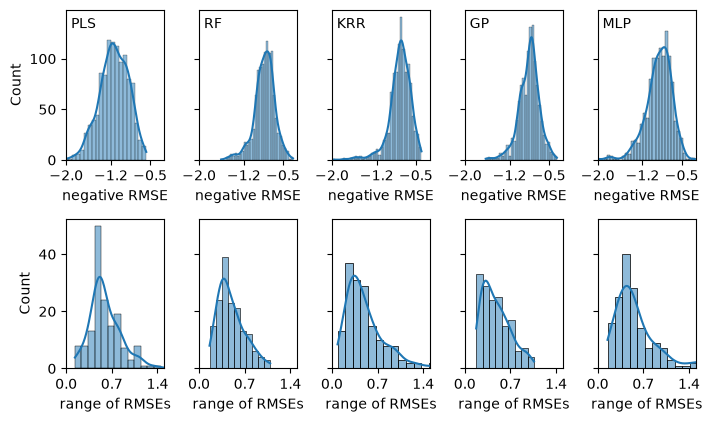

In [4]:
import itertools

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

kf_data['range'] = kf_data['score'].apply(lambda x: x.max() - x.min())

fig, axs = plt.subplots(ncols=5, nrows=2, layout='tight', sharey='row', sharex='row', figsize=(9*0.8, 6*0.72)) #figsize=(9*0.8, 9*0.72))
for ax, (kind, model) in zip(axs.reshape(-1), itertools.product(('rmse', 'range'), ('pls', 'rf', 'krr', 'gp', 'mlp'))):
    if kind == 'rmse':
        model_data = kf_data[(kf_data['model'] == model)].explode('score').reset_index(drop=True)
        sns.histplot(
            model_data[model_data['score'] > -100], x = 'score', ax=ax, kde=True
        )
        ax.text(0.05, 0.95, f"{model.upper()}", transform=ax.transAxes, fontsize=10,
                verticalalignment='top')
        ax.set(xlim=(-2, -0.25), xticks=(-2, -1.2, -0.5))
        ax.set(xlabel=("negative RMSE"))
    else:
        model_data = kf_data[(kf_data['model'] == model)]
        sns.histplot(
            model_data[model_data['range'] < 100], x = 'range', ax=ax, kde=True
        )
        ax.set(xlim=(0, 1.5), xticks=(0, 0.7, 1.4))
        ax.set(xlabel=("range of RMSEs"))
os.makedirs(Path(os.getcwd()) / "plots" / "evaluation", exist_ok=True)
plt.savefig(Path(os.getcwd()) / "plots" / "evaluation" / "figure3.pdf", dpi=1500, bbox_inches="tight")
plt.show()

## Figure 4

In [ ]:
# We need to patch the fit and predict methods of the merf package.
# As the package was not initially designed to act as sklearn estimator
# stuff breaks inside a nested cv.
# This is caused by an index mismatch on the cluster array, which MUST be a
# pandas Series in the merf package, but nesting group leave-outs destroys indizes
# and we need the cluster given as numpy array instead.
# To avoid rewriting the whole function, we perform a dirty live patch
# of the predict function when using it, by applying a patch to the function
# source code interpreted as temporary file (this approach is due to gemini).
# The patch diffs are in merf_fit.diff resp. merf_predict.diff.

# To avaoid hiding this, we do this whenever we use the merf package and the
# associated SklearnMERF estimator, instead of hding the patchin close to
# the class.

import inspect
import tempfile
import textwrap
import sys

import patch_ng
import merf

def patch_merf_predict():
    predict_source = textwrap.dedent(inspect.getsource(getattr(merf.MERF, "predict")))

    patch_set = patch_ng.fromfile("analysis/merf_predict.diff")

    # use a tempfile to apply patch to
    with tempfile.NamedTemporaryFile(mode='w', suffix='.py', encoding='utf-8', delete=False) as fh:
        fh.write(predict_source)
        tmp_path = fh.name

    for single_patch in patch_set.items:
        # change patch file name in place
        single_patch.source = tmp_path.encode('utf-8')
        single_patch.target = tmp_path.encode('utf-8')

    try:
        if not patch_set.apply(root=os.path.dirname(tmp_path)):
            raise RuntimeError(f"Failed to cleanly apply the diff to the predict function!")

        with open(tmp_path, 'r') as fh:
            predict_patched = fh.read()
    finally:
        if os.path.exists(tmp_path):
            os.remove(tmp_path)

    merf_globals = sys.modules[merf.MERF.__module__].__dict__
    exec(predict_patched, merf_globals)
    setattr(merf.MERF, 'predict', merf_globals['predict'])

patch_merf_predict()

INFO     [patch_ng.py:1204] successfully patched 1/1:	 b'/tmp/tmp70lfn3yr.py'


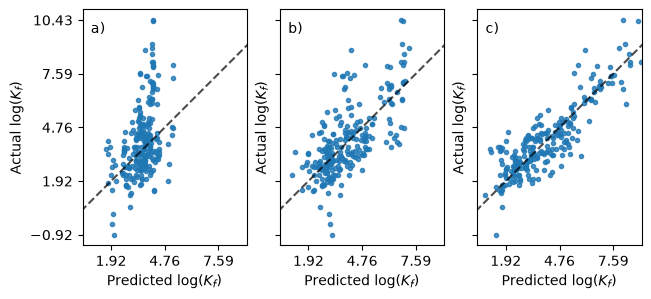

In [ ]:
from training.grouped_training import SklearnMERF

MODEL_DIR = Path(os.getcwd()) / "models"

def example_model_path(model_type, embedding, group_split, merf=False):
    path_pref = MODEL_DIR / "leavexout"
    if merf:
        path_pref /= f"{group_split}_merf"
    else:
        path_pref /= group_split
        
    path = model_path(
        DataSettings(
            r2_cutoff=0.85, conc_range=False, salinity='all_water',
            temperature=True, sorbent='name'),
            path_prefix=path_pref
        )
    path /= model_name(ModelSettings(model=model_type, embedding=embedding, target='kf'))
    return path


fig, axs = plt.subplots(ncols=3, figsize=(8*0.8, 4*0.72), layout='constrained', sharey=True)
for (model, emb, split, merf, ax) in (
    ('rf', 'abrahams', 'publication', True, axs[0]),
    ('krr', 'abrahams', 'polymer', False, axs[1]),
    ('krr', 'abrahams', 'sorbate', False, axs[2]),
):
    with open(example_model_path(model, emb, split, merf), 'rb') as fh:
        (X, y), clf, grid, (inner_cv, outer_cv), score = pickle.load(fh)
    y_pred = np.zeros_like(y)
    for est, ind in zip(score['estimator'], score['indices']['test']):
        y_pred[ind] = est.predict(X.iloc[ind])
    PredictionErrorDisplay.from_predictions(y, y_pred, kind='actual_vs_predicted', ax=ax, scatter_kwargs={'marker':'.'})
    ax.set(xlabel=f"Predicted log($K_f$)", ylabel=f"Actual log($K_f$)")
for i, ax in enumerate(axs):
    ax.text(0.05,0.9,chr(i+97)+')', transform=ax.transAxes)
os.makedirs(Path(os.getcwd()) / "plots" / "evaluation", exist_ok=True)
plt.savefig(Path(os.getcwd()) / "plots" / "evaluation" / "figure4.pdf", dpi=1500, bbox_inches="tight")
plt.show()


# Supplement
## Cross Validation Results (S11)

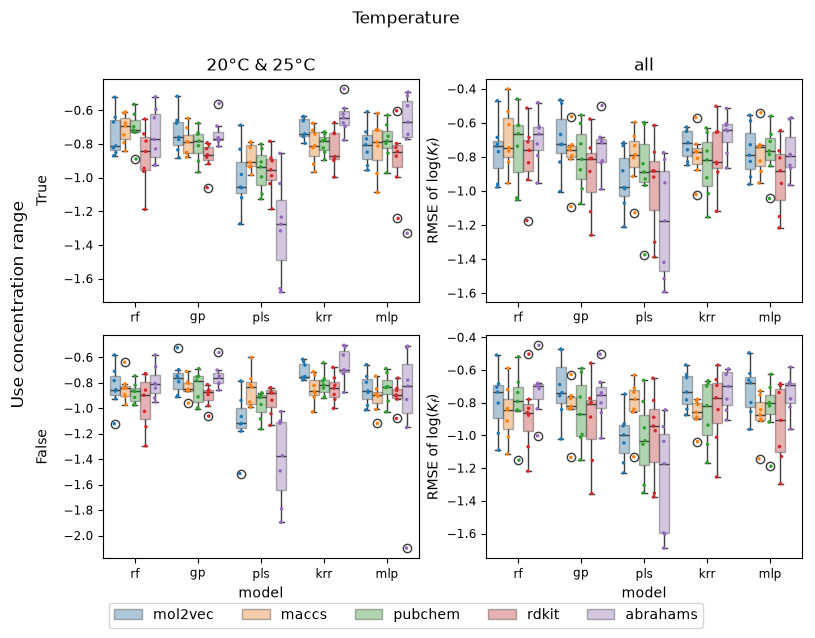

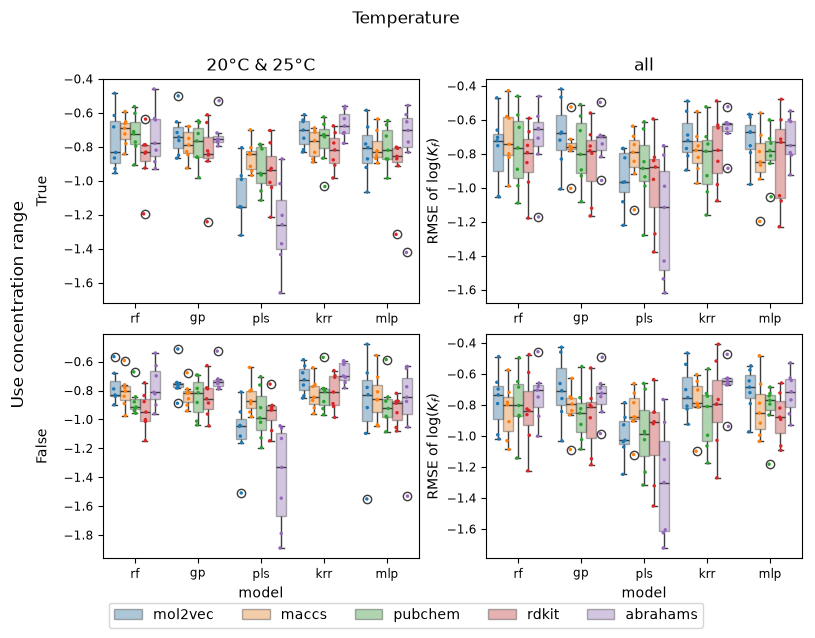

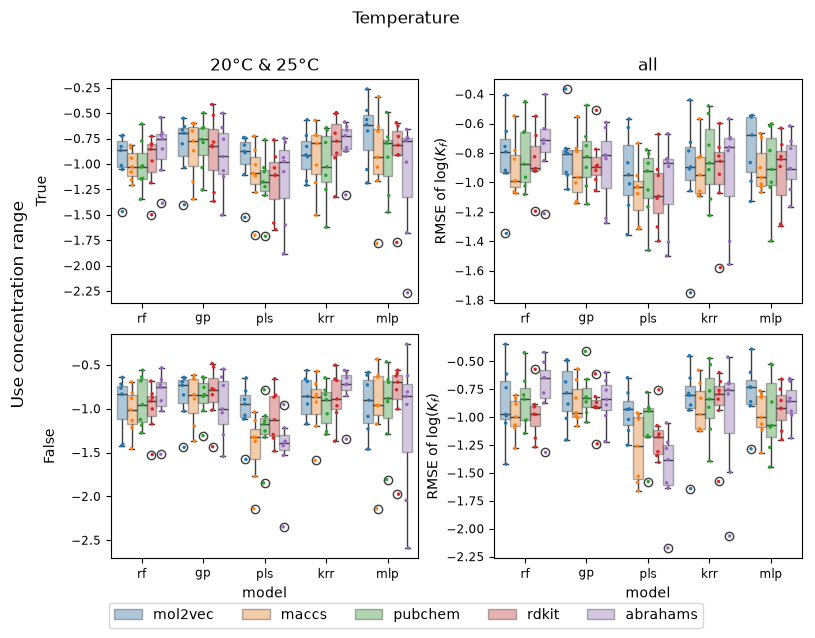

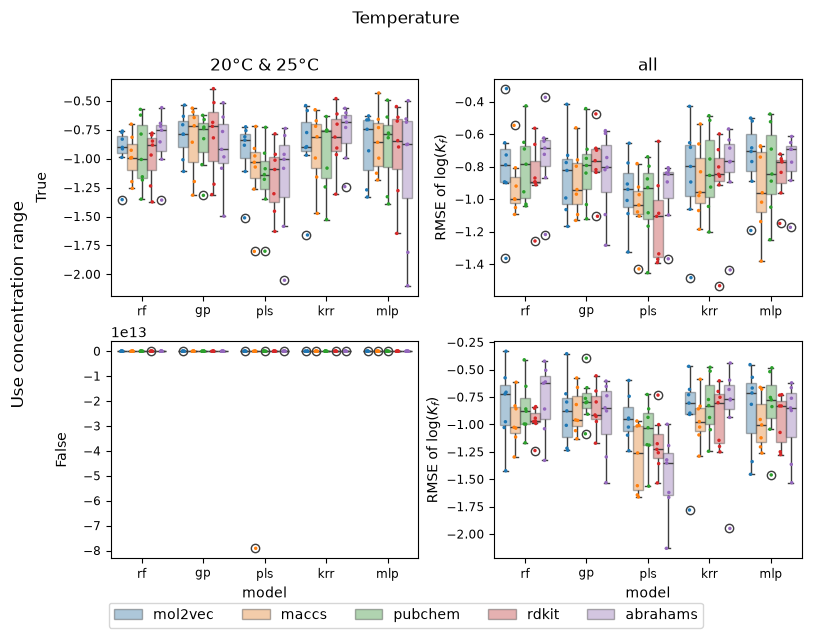

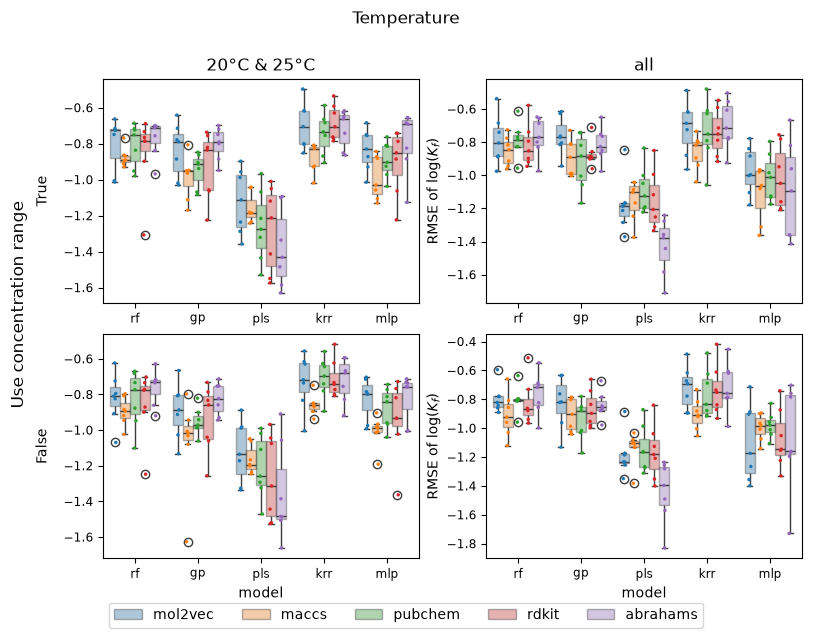

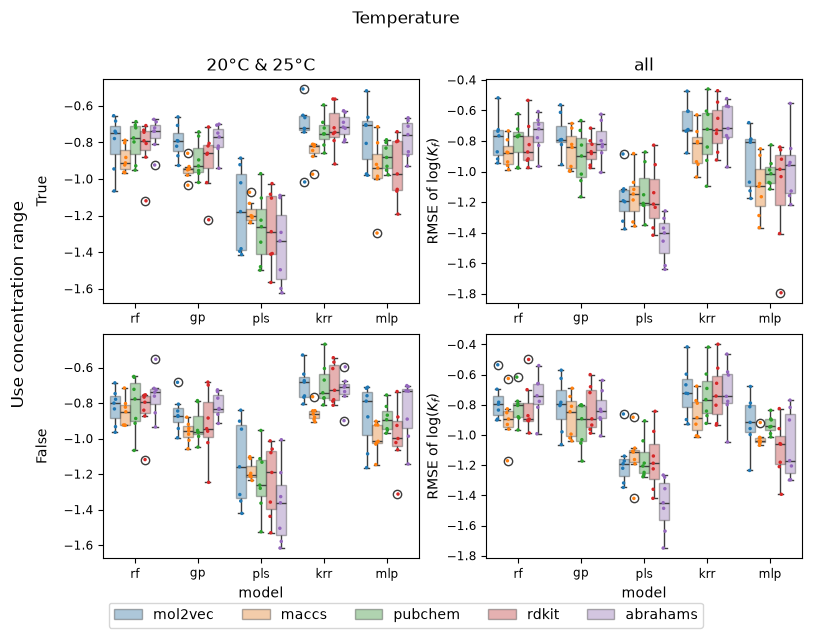

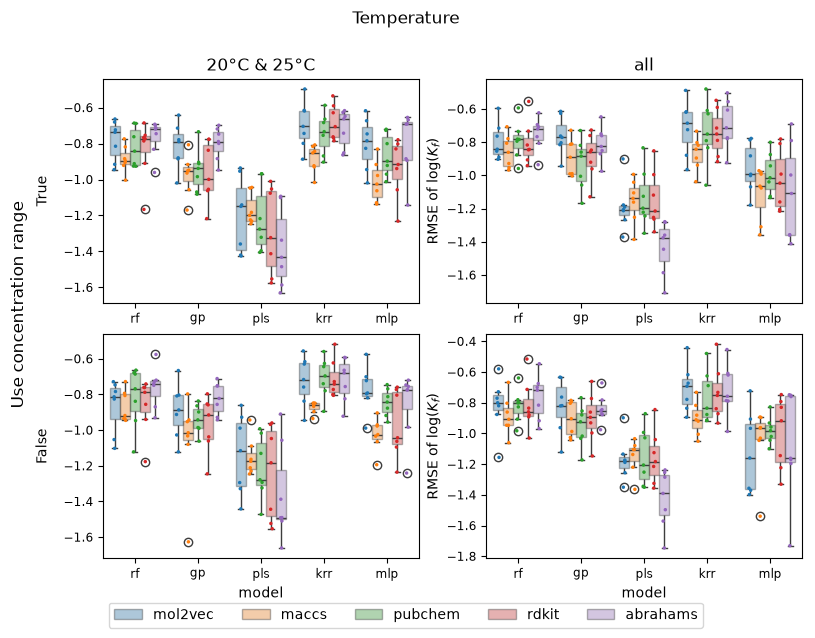

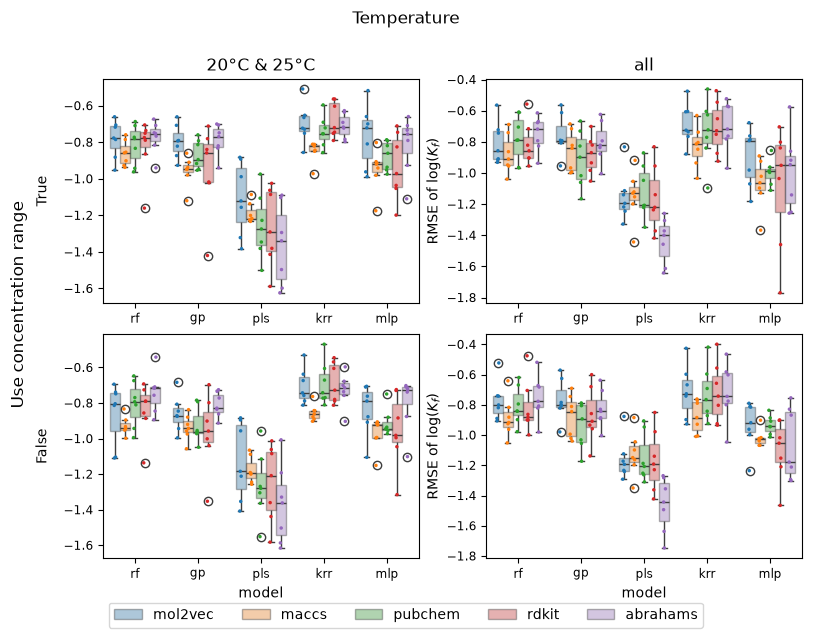

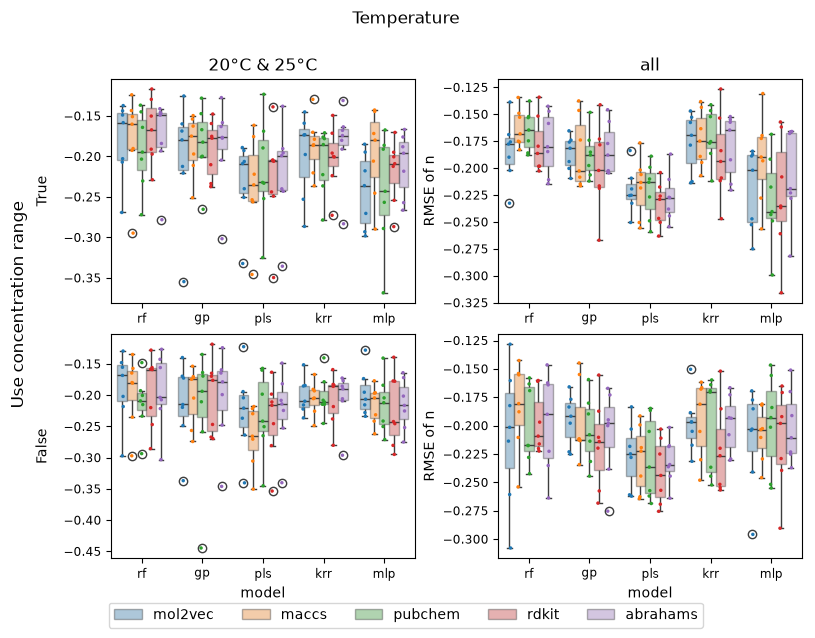

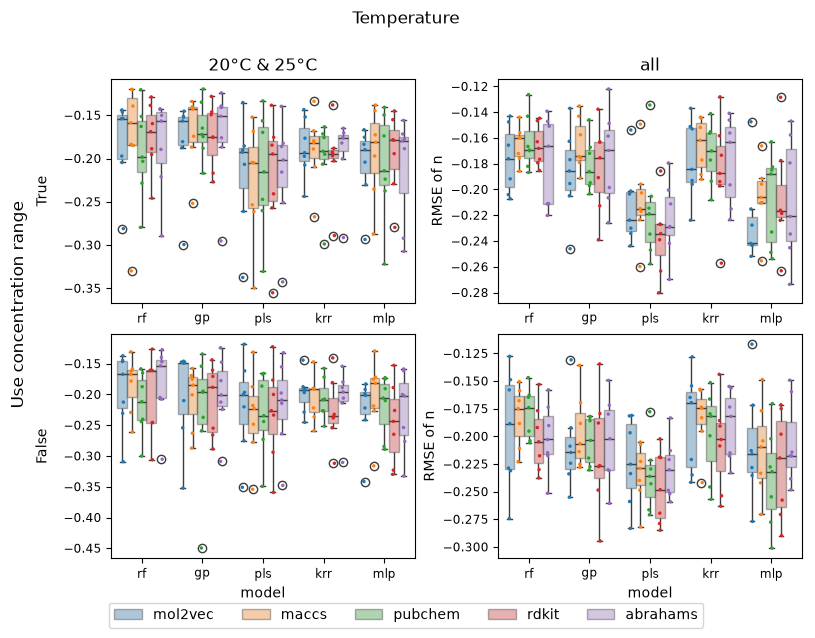

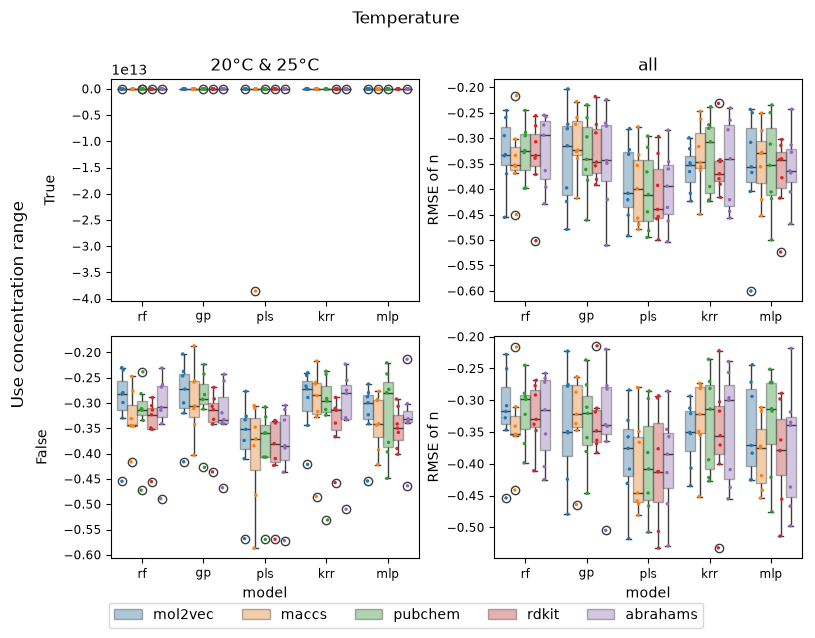

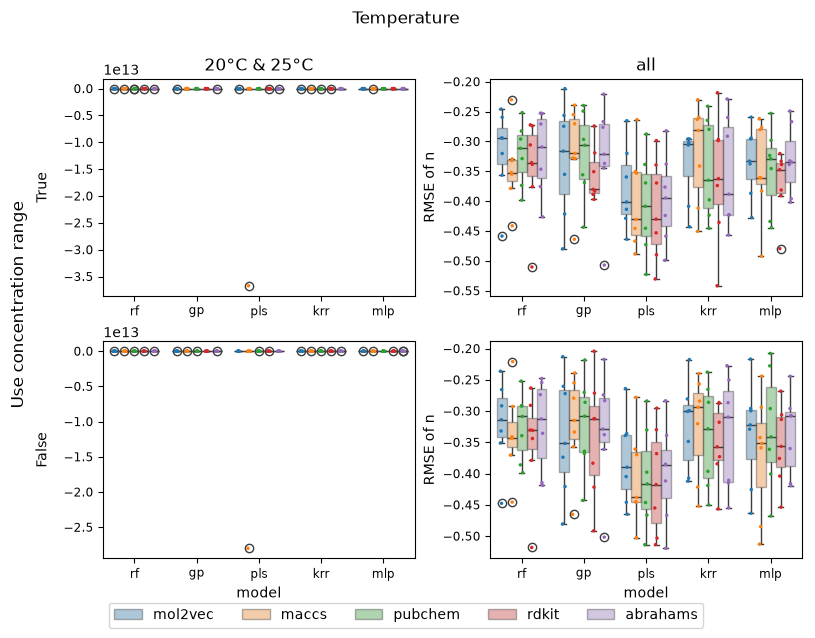

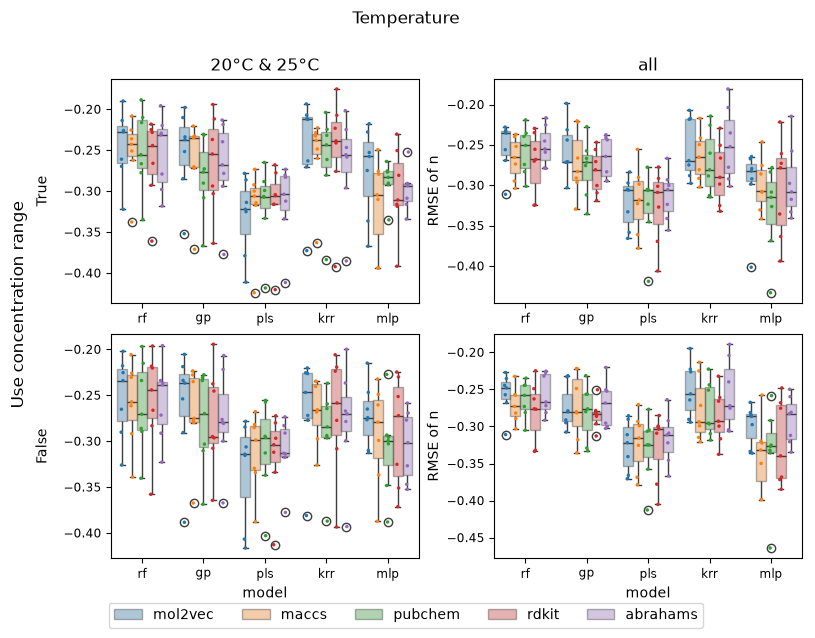

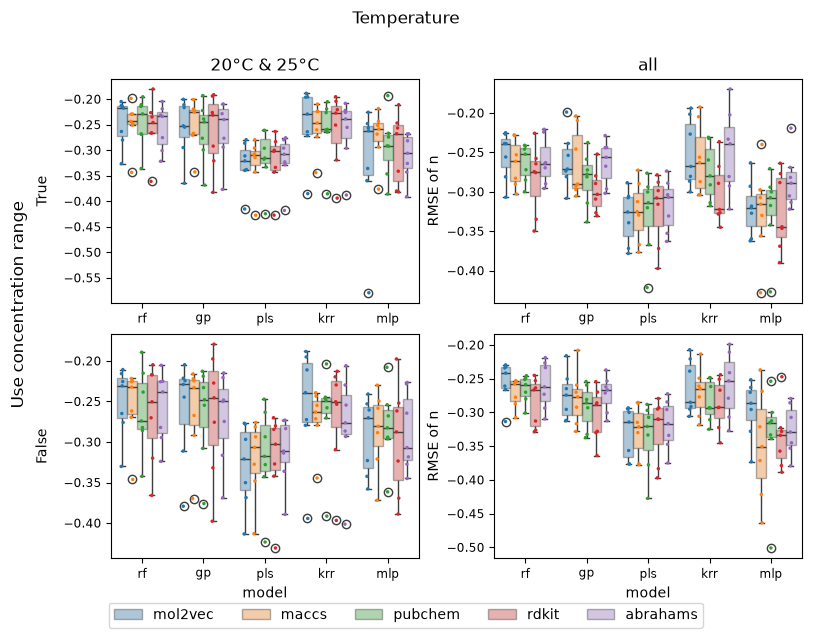

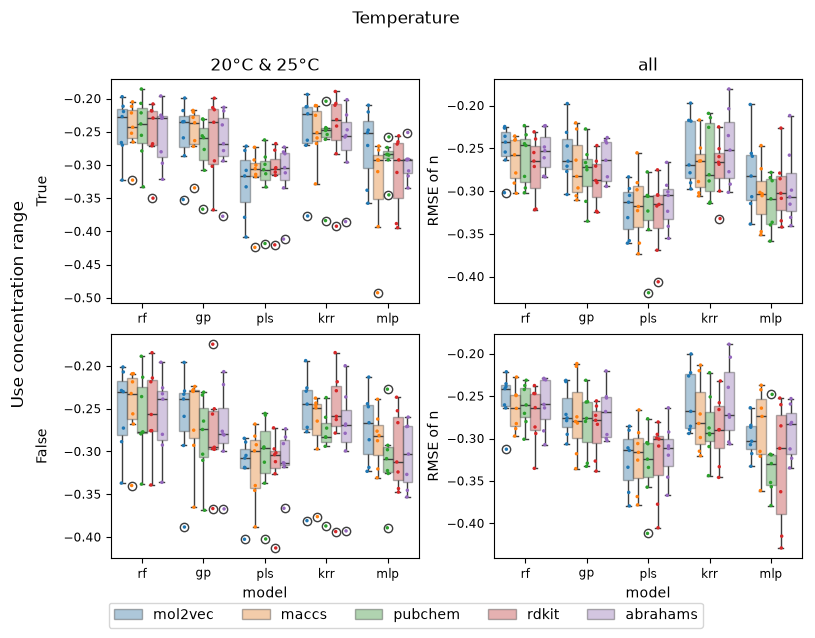

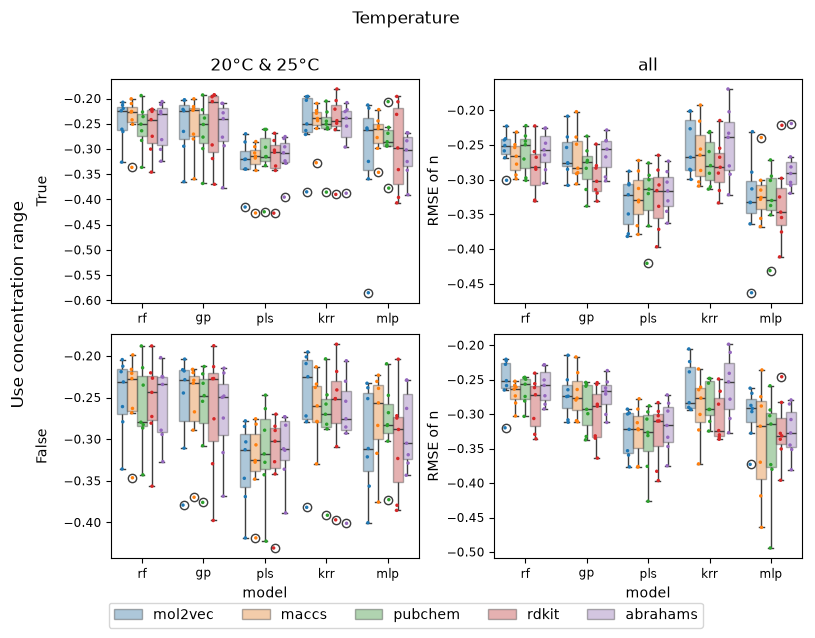

In [34]:
from matplotlib import pyplot as plt
import seaborn as sns

def _plot_bow_facet(data, sorbent, targetname, hue='fingerprint'):
    x = 'model' if hue == 'fingerprint' else 'fingerprint'
    data_dict = {
        221: data[(data['crange'] == True) & (data['temperature'] == False) & (data['sorbent'] == sorbent)],
        222: data[(data['crange'] == True) & (data['temperature'] == True) & (data['sorbent'] == sorbent)],
        223: data[(data['crange'] == False) & (data['temperature'] == False) & (data['sorbent'] == sorbent)],
        224: data[(data['crange'] == False) & (data['temperature'] == True) & (data['sorbent'] == sorbent)],
    }
    # stripplot integration
    # copyright cc-by-sa johanC https://stackoverflow.com/a/67374479
    fig = plt.figure(layout='constrained', figsize=(8, 6))
    fig.subfigures(2, 1)
    needs_legend = True
    handles, labels = None, None
    for place, data in data_dict.items():
        sns.boxplot(
            data=data.dropna(axis='rows', how='any').explode(column='score').reset_index(),
            x=x, y='score', hue=hue, legend=needs_legend,
            boxprops={'alpha': 0.4}, ax=plt.subplot(place)
        )
        if needs_legend:
            handles, labels = plt.gca().get_legend_handles_labels()
            needs_legend = False
            plt.gca().get_legend().remove()
        sns.stripplot(
            data=data.dropna(axis='rows', how='any').explode(column='score').reset_index(),
            x=x, y='score', hue=hue, legend=needs_legend,
            dodge=True, s=2.5, ax=plt.subplot(place)
        )
        plt.subplot(place).tick_params(axis='both', labelsize='small')
    fig.supylabel("Use concentration range")
    plt.subplot(221).set_title("20°C & 25°C")
    plt.subplot(221).set_xlabel("")
    plt.subplot(221).set_ylabel("True", labelpad=10)
    plt.subplot(222).set_xlabel("")
    plt.subplot(222).set_ylabel(f"RMSE of {targetname}")
    plt.subplot(222).set_title("all")
    plt.subplot(223).set_ylabel("False", labelpad=10)
    plt.subplot(224).set_ylabel(f"RMSE of {targetname}")
    fig.suptitle("Temperature\n ")
    fig.legend(
        handles, labels, loc='outside lower center', bbox_to_anchor=(0.5, -0.05),
                ncols=5
    )

# boxplots for all settings (S12.1)
plot_path = Path(os.getcwd()) / "plots" / "suppl"
os.makedirs(plot_path, exist_ok=True)
for param in ('kf', 'n'):
    all_data = kf_data if param == 'kf' else n_data
    targetname = r"$\log(K_f)$" if param == 'kf' else "n"
    for salinity in ("freshwater", "seawater", "all_water", "all_vals"):
        _plot_bow_facet(all_data[all_data['salinity'] == salinity], sorbent='name', targetname=targetname)
        plt.savefig(plot_path / f"{param}_name_{salinity}_group_embeddings.pdf", dpi=1500, bbox_inches="tight")
        plt.show()
        _plot_bow_facet(all_data[all_data['salinity'] == salinity], sorbent='comp', targetname=targetname)
        plt.savefig(plot_path / f"{param}_composition_{salinity}_group_embeddings.pdf", dpi=1500, bbox_inches="tight")
        plt.show()


## RMSE Distributions (S12)
### RMSEs partitioned by model and fingerprint

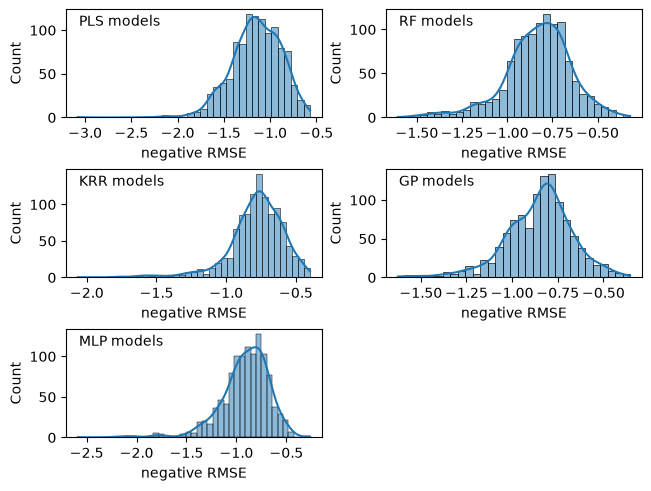

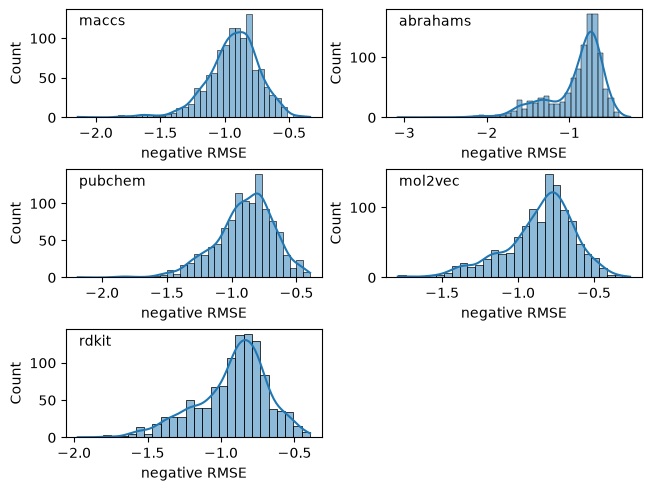

In [35]:
fig, axs = plt.subplots(ncols=2, nrows=3, layout='constrained')
for ax, model in zip(axs.reshape(-1), ('pls', 'rf', 'krr', 'gp', 'mlp')):
    model_data = kf_data[(kf_data['model'] == model)].explode('score').reset_index(drop=True)
    sns.histplot(
        model_data[model_data['score'] > -100], x = 'score', ax=ax, kde=True
    )
    ax.text(0.05, 0.95, f"{model.upper()} models", transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.set(xlabel=("negative RMSE"))
axs.reshape(-1)[-1].remove()
# axs[1].axvline(
#     kf_data[(kf_data['model'] != 'pls')].explode('score').reset_index(drop=True)['score'].median(),
#     color='k', linestyle='dashed', linewidth=1
# )
os.makedirs(Path(os.getcwd()) / "plots" / "suppl", exist_ok=True)
plt.savefig(Path(os.getcwd()) / "plots" / "suppl" / "figureS13-models.pdf", dpi=1500, bbox_inches="tight")
plt.show()

fig, axs = plt.subplots(ncols=2, nrows=3, layout='constrained') #figsize=(9*0.8, 9*0.72))
for ax, emb in zip(axs.reshape(-1), ('maccs', 'abrahams', 'pubchem', 'mol2vec', 'rdkit')):
    model_data = kf_data[(kf_data['fingerprint'] == emb)].explode('score').reset_index(drop=True)
    sns.histplot(
        model_data[model_data['score'] > -100], x = 'score', ax=ax, kde=True
    )
    ax.text(0.05, 0.95, f"{emb}", transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.set(xlabel=("negative RMSE"))
axs.reshape(-1)[-1].remove()
# axs[1].axvline(
#     kf_data[(kf_data['model'] != 'pls')].explode('score').reset_index(drop=True)['score'].median(),
#     color='k', linestyle='dashed', linewidth=1
# )
os.makedirs(Path(os.getcwd()) / "plots" / "suppl", exist_ok=True)
plt.savefig(Path(os.getcwd()) / "plots" / "suppl" / "figureS13-embeddings.pdf", dpi=1500, bbox_inches="tight")
plt.show()

### ranges of the RMSEs partitioned by model and fingerprint

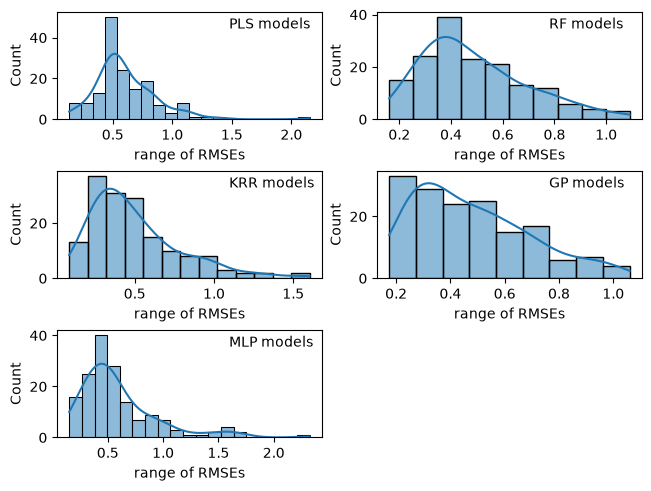

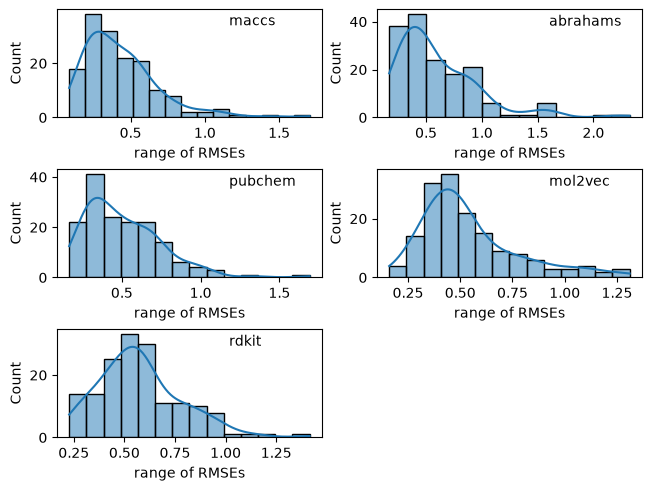

In [36]:
kf_data['range'] = kf_data['score'].apply(lambda x: x.max() - x.min())
fig, axs = plt.subplots(ncols=2, nrows=3, layout='constrained') #figsize=(9*0.8, 9*0.72))
for ax, model in zip(axs.reshape(-1), ('pls', 'rf', 'krr', 'gp', 'mlp')):
    model_data = kf_data[(kf_data['model'] == model)]
    sns.histplot(
        model_data[model_data['range'] < 100], x = 'range', ax=ax, kde=True
    )
    ax.text(0.65, 0.95, f"{model.upper()} models", transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.set(xlabel=("range of RMSEs"))
axs.reshape(-1)[-1].remove()
# axs[1].axvline(
#     kf_data[(kf_data['model'] != 'pls')].explode('score').reset_index(drop=True)['score'].median(),
#     color='k', linestyle='dashed', linewidth=1
# )
os.makedirs(Path(os.getcwd()) / "plots" / "suppl", exist_ok=True)
plt.savefig(Path(os.getcwd()) / "plots" / "suppl" / "figureS13-models_range.pdf", dpi=1500, bbox_inches="tight")
plt.show()

fig, axs = plt.subplots(ncols=2, nrows=3, layout='constrained') #figsize=(9*0.8, 9*0.72))
for ax, emb in zip(axs.reshape(-1), ('maccs', 'abrahams', 'pubchem', 'mol2vec', 'rdkit')):
    model_data = kf_data[(kf_data['fingerprint'] == emb)]
    sns.histplot(
        model_data[model_data['range'] < 100], x = 'range', ax=ax, kde=True
    )
    ax.text(0.65, 0.95, f"{emb}", transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.set(xlabel=("range of RMSEs"))
axs.reshape(-1)[-1].remove()
# axs[1].axvline(
#     kf_data[(kf_data['model'] != 'pls')].explode('score').reset_index(drop=True)['score'].median(),
#     color='k', linestyle='dashed', linewidth=1
# )
os.makedirs(Path(os.getcwd()) / "plots" / "suppl", exist_ok=True)
plt.savefig(Path(os.getcwd()) / "plots" / "suppl" / "figureS13-embeddings_range.pdf", dpi=1500, bbox_inches="tight")
plt.show()

### RMSEs and ranges thereof partitioned by salinity

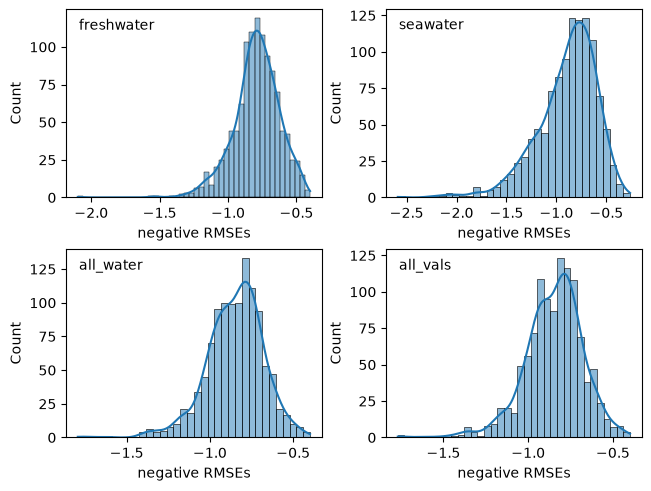

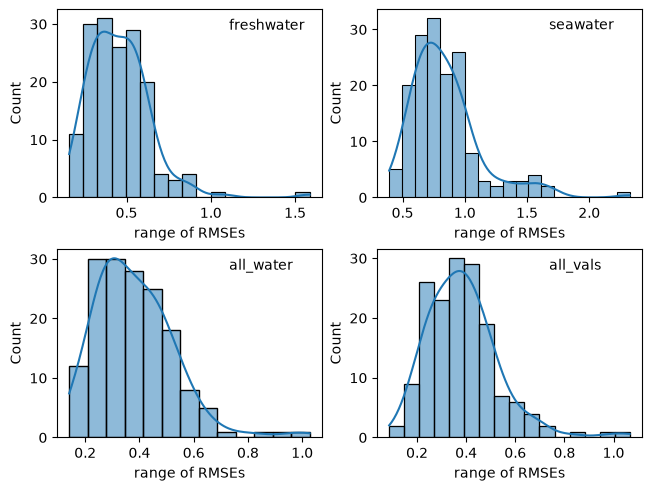

In [37]:
kf_data['range'] = kf_data['score'].apply(lambda x: x.max() - x.min())
fig, axs = plt.subplots(ncols=2, nrows=2, layout='constrained') #figsize=(9*0.8, 9*0.72))
for ax, sal in zip(axs.reshape(-1), ('freshwater', 'seawater', 'all_water', 'all_vals')):
    model_data = kf_data[(kf_data['salinity'] == sal) & (kf_data['model'] != 'pls')].explode('score').reset_index(drop=True)
    sns.histplot(
        model_data[model_data['score'] > -100], x='score', ax=ax, kde=True
    )
    ax.text(0.05, 0.95, f"{sal}", transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.set(xlabel=("negative RMSEs"))
# axs[1].axvline(
#     kf_data[(kf_data['model'] != 'pls')].explode('score').reset_index(drop=True)['score'].median(),
#     color='k', linestyle='dashed', linewidth=1
# )
os.makedirs(Path(os.getcwd()) / "plots" / "suppl", exist_ok=True)
plt.savefig(Path(os.getcwd()) / "plots" / "suppl" / "figureS13-salinity.pdf", dpi=1500, bbox_inches="tight")
plt.show()

fig, axs = plt.subplots(ncols=2, nrows=2, layout='constrained') #figsize=(9*0.8, 9*0.72))
for ax, sal in zip(axs.reshape(-1), ('freshwater', 'seawater', 'all_water', 'all_vals')):
    model_data = kf_data[(kf_data['salinity'] == sal) & (kf_data['model'] != 'pls')]
    sns.histplot(
        model_data[model_data['range'] < 100], x = 'range', ax=ax, kde=True
    )
    ax.text(0.65, 0.95, f"{sal}", transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.set(xlabel=("range of RMSEs"))
# axs[1].axvline(
#     kf_data[(kf_data['model'] != 'pls')].explode('score').reset_index(drop=True)['score'].median(),
#     color='k', linestyle='dashed', linewidth=1
# )
os.makedirs(Path(os.getcwd()) / "plots" / "suppl", exist_ok=True)
plt.savefig(Path(os.getcwd()) / "plots" / "suppl" / "figureS13-salinity_range.pdf", dpi=1500, bbox_inches="tight")
plt.show()

## Kf, n and temperature (S13)

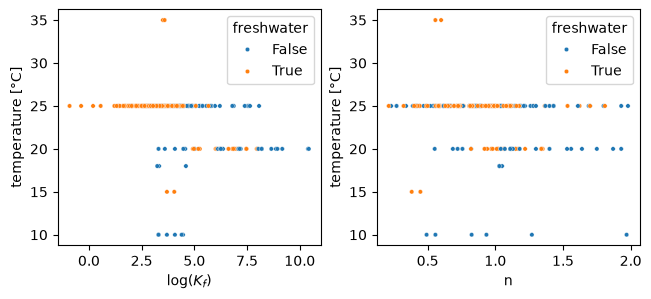

In [38]:
import os
from pathlib import Path

from matplotlib import pyplot as plt
import seaborn as sns

from training.train_utils import get_data, DataSettings, ModelSettings

X, y, _ = get_data(
    DataSettings(0.85, True, 'all_water', True, 'name'),
    ModelSettings(None, 'raw', 'kf'),
    Path('data')
)

_, y_n, _ = get_data(
    DataSettings(0.85, True, 'all_water', True, 'name'),
    ModelSettings(None, 'raw', 'n'),
    Path('data')
)
X['kf'] = y
X['n'] = y_n
X['freshwater'] = ~X['seawater']
fig, axs = plt.subplots(ncols=2, figsize=(8*0.8, 4*0.72), layout='constrained')
sns.scatterplot(X, x = 'n', y = 'T', hue='freshwater', ax=axs[1], s=10)
axs[1].set(ylabel="temperature [°C]")
sns.scatterplot(X, x = 'kf', y = 'T', hue='freshwater', ax=axs[0], s=10)
axs[0].set(ylabel="temperature [°C]", xlabel=r"$\log(K_f)$")
os.makedirs(Path(os.getcwd()) / "plots" / "suppl", exist_ok=True)
plt.savefig(Path(os.getcwd()) / "plots" / "suppl" / "figureS14.pdf", dpi=1500, bbox_inches="tight")
plt.show()
